In [19]:
# Ejemplo de EDA: Formular hipótesis
# Importar librerías 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
# Leer datos
file_path = "C:/Git/vehicles_env/datasets/auto_cons_us.csv"
cars = pd.read_csv(file_path) # Cargar dataframe
print(cars.shape) # Mostrar el tamaño del dataframe

(398, 8)


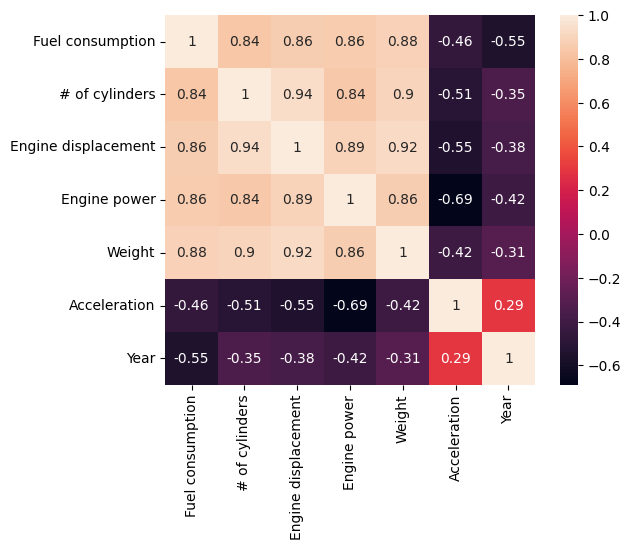

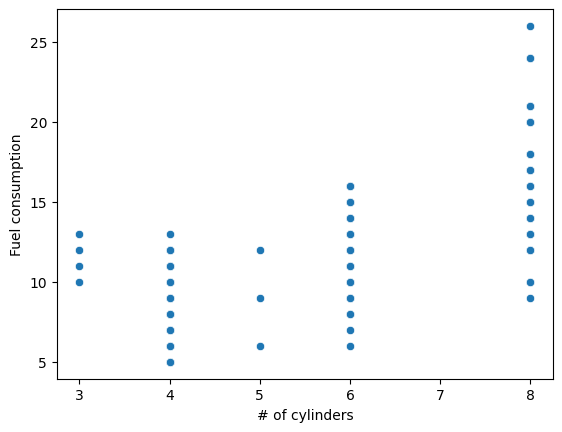

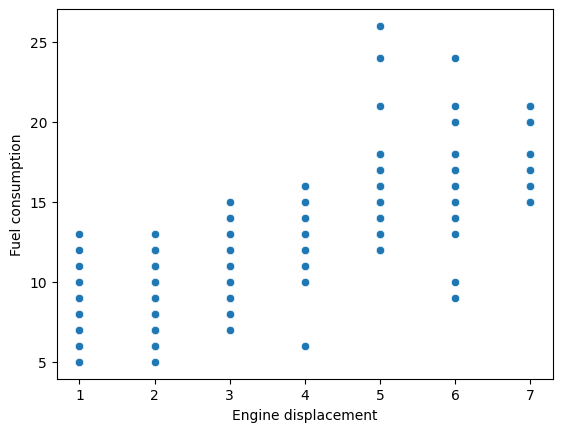

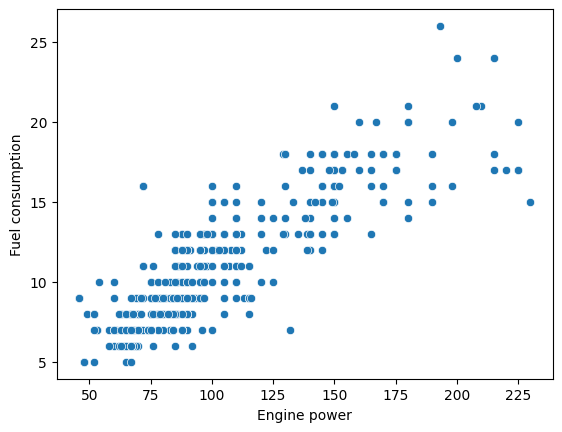

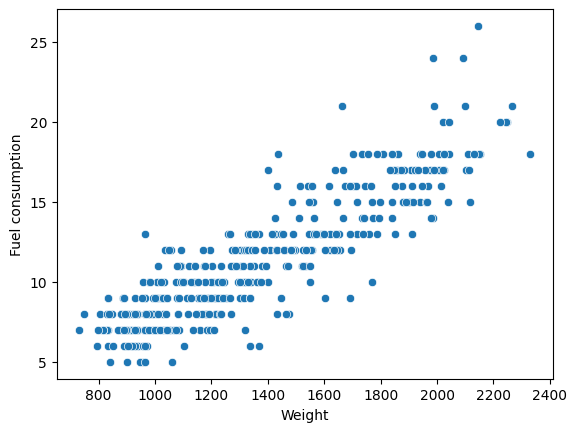

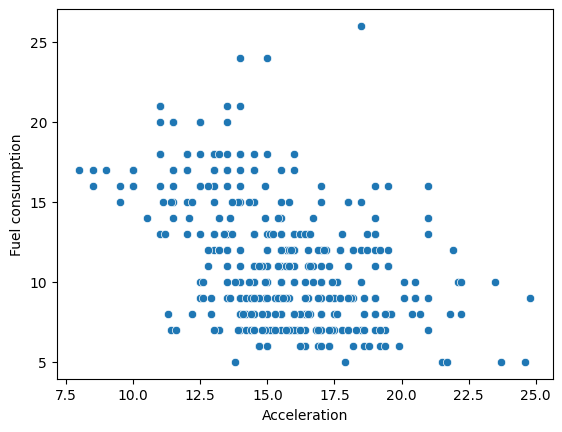

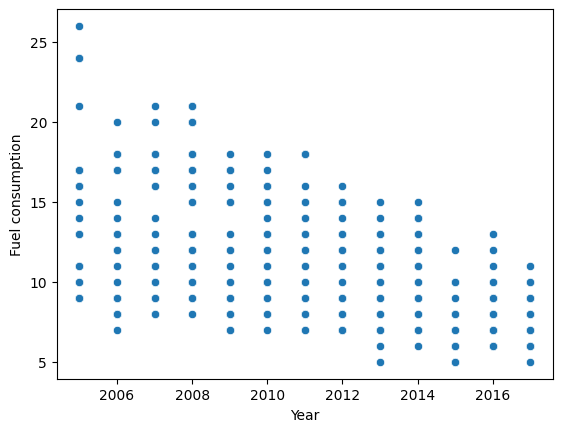

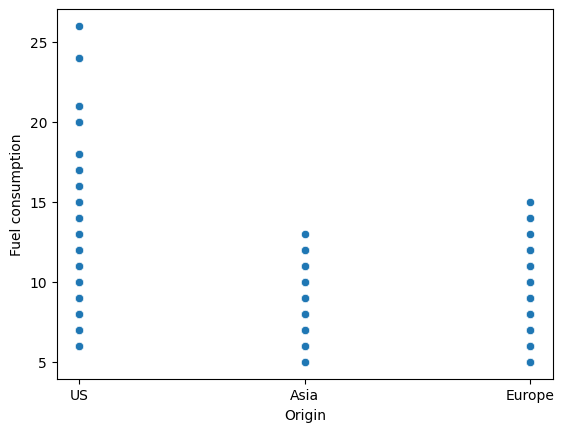

In [27]:
# construye y representa una matriz de correlación
cm = cars.corr(numeric_only=True) # calcula la matriz de correlación solo con las columnas numéricas
fig, ax = plt.subplots()

# traza el mapa de calor anotado para la matriz de correlación
sns.heatmap(cm, annot=True, square=True)
ax.set_ylim(7, 0) # corrige los campos "irregulares" del mapa de calor en la última versión de la librería
plt.show()

# traza diagramas de distribución pareada de característica - variable objetivo para cada característica
for col in cars.drop('Fuel consumption', axis=1).columns:
    sns.scatterplot(x=cars[col], y=cars['Fuel consumption'])    
    plt.show()

### 1) ¿Hay algún valor atípico claro entre las características?

* **Sí, pocos coches con consumo muy alto** (≈ 24–26) sobresalen respecto al resto.
* También hay **motores muy grandes/potentes** (desplazamiento 6–7, potencia >200) y **aceleraciones extremas** (muy lentas, ≈ 24–25 s).
  No son muchos, pero son los puntos “más alejados” en los dispersogramas.

### 2) ¿Hay alguna característica con una fuerte correlación mutua?

Claramente sí (se mueven “en combo”):

* **Cilindros ↔ Desplazamiento** ≈ **0.94**
* **Desplazamiento ↔ Peso** ≈ **0.92**
* **Cilindros ↔ Peso** ≈ **0.90**
* **Potencia** también va muy de la mano con esas tres (≈ **0.84–0.89**).
  Traducción: *motores grandes* suelen tener **más cilindros**, **más potencia** y el coche suele ser **más pesado**. Es la misma idea repetida con distintas medidas.

> Nota práctica: como esas variables cuentan casi lo mismo, si luego haces un modelo lineal, no metas **todas** a la vez; elige 1–2 o combina (si usas árboles/bosques esto molesta menos).

### 3) ¿Hay alguna característica que tenga una fuerte correlación con "Consumo de combustible", la variable objetivo?

Sí, varias, y bastante:

* **Peso** ≈ **0.88** (más peso ⇒ más consumo)
* **Desplazamiento** ≈ **0.86**
* **Potencia** ≈ **0.86**
* **Cilindros** ≈ **0.84**
  Y relaciones **negativas** (a más valor, menos consumo):
* **Año** ≈ **−0.55** (coches más nuevos consumen menos)
* **Aceleración** ≈ **−0.46** (más segundos = coche más “lento”; suelen consumir menos)

En resumen: **el consumo está muy ligado al tamaño y músculo del coche** (peso, cilindros, cilindrada, potencia). Los **años recientes** tienden a consumir menos. Hay **pocos outliers** arriba del consumo. Para modelar, quita redundancias entre *peso/cilindros/cilindrada/potencia* o usa un modelo que tolere bien que vayan “de la mano” (p. ej., Random Forest).
